# Step 8: Manuscript Figures

Russell Blessing

## Overview

This notebook builds the manuscript figures from the finalized outputs of the earlier pipeline steps. The first deliverable is **Fig. 2** — the *flooded-to-funded* pipeline funnel.

The pipeline tracks residential properties through five sequential, nested stages:

| \# | Stage | Definition | Source |
|--------|-----------------|----------------------------|-------------------|
| 1 | **flooded** | intersected the footprint of ≥ 1 of the 78 modelled events | Step 7 |
| 2 | **eligible** | flooded during an event for which its county received a PDD | Step 7 |
| 3 | **in a community** | its community (city, else county) is one where the local government assisted with the submission of ≥ 1 HMA application | Step 5 `apps_pcls` |
| 4 | **applied** | the property itself is named on an HMA application | Step 5 `apps_pcls` |
| 5 | **funded** | the property received a mitigation | Step 5 `mits_pcls` |

The funnel is computed twice: once for **all** flood-exposed residential properties, and once for the subset exposed to flooding **more than once**.

In [ ]:
library(sf)


Linking to GEOS 3.12.0, GDAL 3.11.0, PROJ 9.2.1; sf_use_s2() is TRUE


Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

here() starts at /proj/mhinolab/users/rbless/Obstacles

------------------------------------------------------------------------

## 1 Configuration

In [ ]:
out_dir <- "/proj/mhinolab/users/rbless/data/Obstacles_Output"

cfg <- list(
  master_path      = file.path(out_dir, "parcels_master.gpkg"),
  repeat_threshold = 2L
)


------------------------------------------------------------------------

## 2 Diagnostic — what is actually in the files

In [ ]:
needed <- c("parcel_index", "cntyfips", "SITUS.CITY",
            "flooded_any", "eligible", "fr_1_4", "interpolate",
            "value", "cent_lat", "cent_lng", "eif_lat", "eif_lon",
            "applied", "funded", "pct_white_2020", "pct_black_2020")

master_cols <- names(st_read(cfg$master_path, quiet = TRUE,
  query = "SELECT * FROM \"parcels_master\" LIMIT 0"))

for (w in needed) {
  cat(if (w %in% master_cols) "[ok]  " else "[MISS] ", w, "\n", sep = "")
}


[ok]  parcel_index
[ok]  cntyfips
[ok]  SITUS.CITY
[ok]  flooded_any
[ok]  eligible
[ok]  fr_1_4
[ok]  interpolate
[ok]  value
[ok]  cent_lat
[ok]  cent_lng
[ok]  eif_lat
[ok]  eif_lon
[ok]  applied
[ok]  funded
[ok]  pct_white_2020
[ok]  pct_black_2020

------------------------------------------------------------------------

## 3 Load finalized datasets

In [ ]:
parcels <- st_read(cfg$master_path, quiet = TRUE) |>
  st_drop_geometry() |>
  transmute(
    parcel_index   = as.integer(parcel_index),
    county         = as.character(cntyfips),
    city           = as.character(SITUS.CITY),
    flood_ct       = suppressWarnings(as.numeric(flooded_any)),
    elig_ct        = suppressWarnings(as.numeric(eligible)),
    res_flag       = suppressWarnings(as.integer(fr_1_4)),
    interpolate    = suppressWarnings(as.integer(interpolate)),
    value          = suppressWarnings(as.numeric(value)),
    lat            = suppressWarnings(as.numeric(cent_lat)),
    lng            = suppressWarnings(as.numeric(cent_lng)),
    eif_lat        = suppressWarnings(as.numeric(eif_lat)),
    eif_lon        = suppressWarnings(as.numeric(eif_lon)),
    applied        = as.logical(applied),
    funded         = as.logical(funded),
    pct_white_2020 = suppressWarnings(as.numeric(pct_white_2020)),
    pct_black_2020 = suppressWarnings(as.numeric(pct_black_2020))
  ) |>
  mutate(
    community = if_else(is.na(city) | str_trim(city) == "",
                        paste0("COUNTY_", county),
                        str_to_upper(str_trim(city)))
  )

cat("parcels loaded:", format(nrow(parcels), big.mark = ","), "\n")


parcels loaded: 4,216,239 

In [ ]:
if ("bg_pct_white_2013" %in% names(parcels)) {
  cat("BG columns already on parcels — skipping load-bg\n")
} else {
  master_bg <- sf::st_read(
    file.path(out_dir, "parcels_master.gpkg"),
    quiet = TRUE,
    query = paste0(
      "SELECT parcel_index, bg_geoid, ",
      "bg_pct_white_2013, bg_pct_black_2013, ",
      "bg_median_income_2013, bg_median_home_value_2013 ",
      "FROM parcels_master"
    )
  ) |>
    sf::st_drop_geometry() |>
    mutate(parcel_index = as.integer(parcel_index))
  
  parcels <- parcels |>
    left_join(master_bg, by = "parcel_index")
  
  cat("Parcels with BG match:",
      format(sum(!is.na(parcels$bg_geoid)), big.mark = ","), "of",
      format(nrow(parcels), big.mark = ","), "\n")
}


Parcels with BG match: 4,213,897 of 4,216,239 

------------------------------------------------------------------------

## 4 Build per-parcel pipeline flags

In [ ]:
# Set of communities where the local government assisted with >=1 HMA
# application (draft Fig. 2 stage-3 definition).
app_communities <- parcels |>
  filter(applied) |>
  distinct(community) |>
  pull(community)

cat("communities with >=1 application:", length(app_communities), "\n")


communities with >=1 application: 356 

------------------------------------------------------------------------

## 5 Funnel table

In [ ]:
funnel_for <- function(df, label) {
  r <- c(sum(df$reach1), sum(df$reach2), sum(df$reach3),
         sum(df$reach4), sum(df$reach5))
  tibble(
    group        = label,
    stage_num    = 1:5,
    stage        = factor(
      c("Flooded", "Eligible", "Community Applied",
        "Applied", "Funded"),
      levels = c("Flooded", "Eligible", "Community Applied",
                 "Applied", "Funded")),
    n            = r,
    pct_of_prev  = c(NA, r[-1] / r[-5]),
    pct_of_flood = r / r[1]
  )
}

funnel_all    <- funnel_for(pipeline,                     "All flood-exposed")
funnel_repeat <- funnel_for(filter(pipeline, repeat_exp), "Repeat flood-exposed")

funnel <- bind_rows(funnel_all, funnel_repeat)

fig_dir <- here::here("figures")
dir.create(fig_dir, showWarnings = FALSE)
readr::write_csv(funnel, file.path(fig_dir, "fig2_funnel_table.csv"))

funnel |>
  mutate(
    n            = format(n, big.mark = ","),
    `% of prev`  = if_else(is.na(pct_of_prev), "—",
                           paste0(round(pct_of_prev * 100, 1), "%")),
    `% of flood` = paste0(round(pct_of_flood * 100, 1), "%")
  ) |>
  select(group, stage, n, `% of prev`, `% of flood`) |>
  knitr::kable()


  -------------------------------------------------------------------------
  group                 stage              n         \% of prev \% of flood
  --------------------- ------------------ --------- ---------- -----------
  All flood-exposed     Flooded            202,623   ---        100%

  All flood-exposed     Eligible           141,253   69.7%      69.7%

  All flood-exposed     Community Applied  132,828   94%        65.6%

  All flood-exposed     Applied            5,746     4.3%       2.8%

  All flood-exposed     Funded             3,432     59.7%      1.7%

  Repeat flood-exposed  Flooded            66,443    ---        100%

  Repeat flood-exposed  Eligible           57,671    86.8%      86.8%

  Repeat flood-exposed  Community Applied  53,912    93.5%      81.1%

  Repeat flood-exposed  Applied            3,705     6.9%       5.6%

  Repeat flood-exposed  Funded             2,166     58.5%      3.3%
  -------------------------------------------------------------------------


------------------------------------------------------------------------

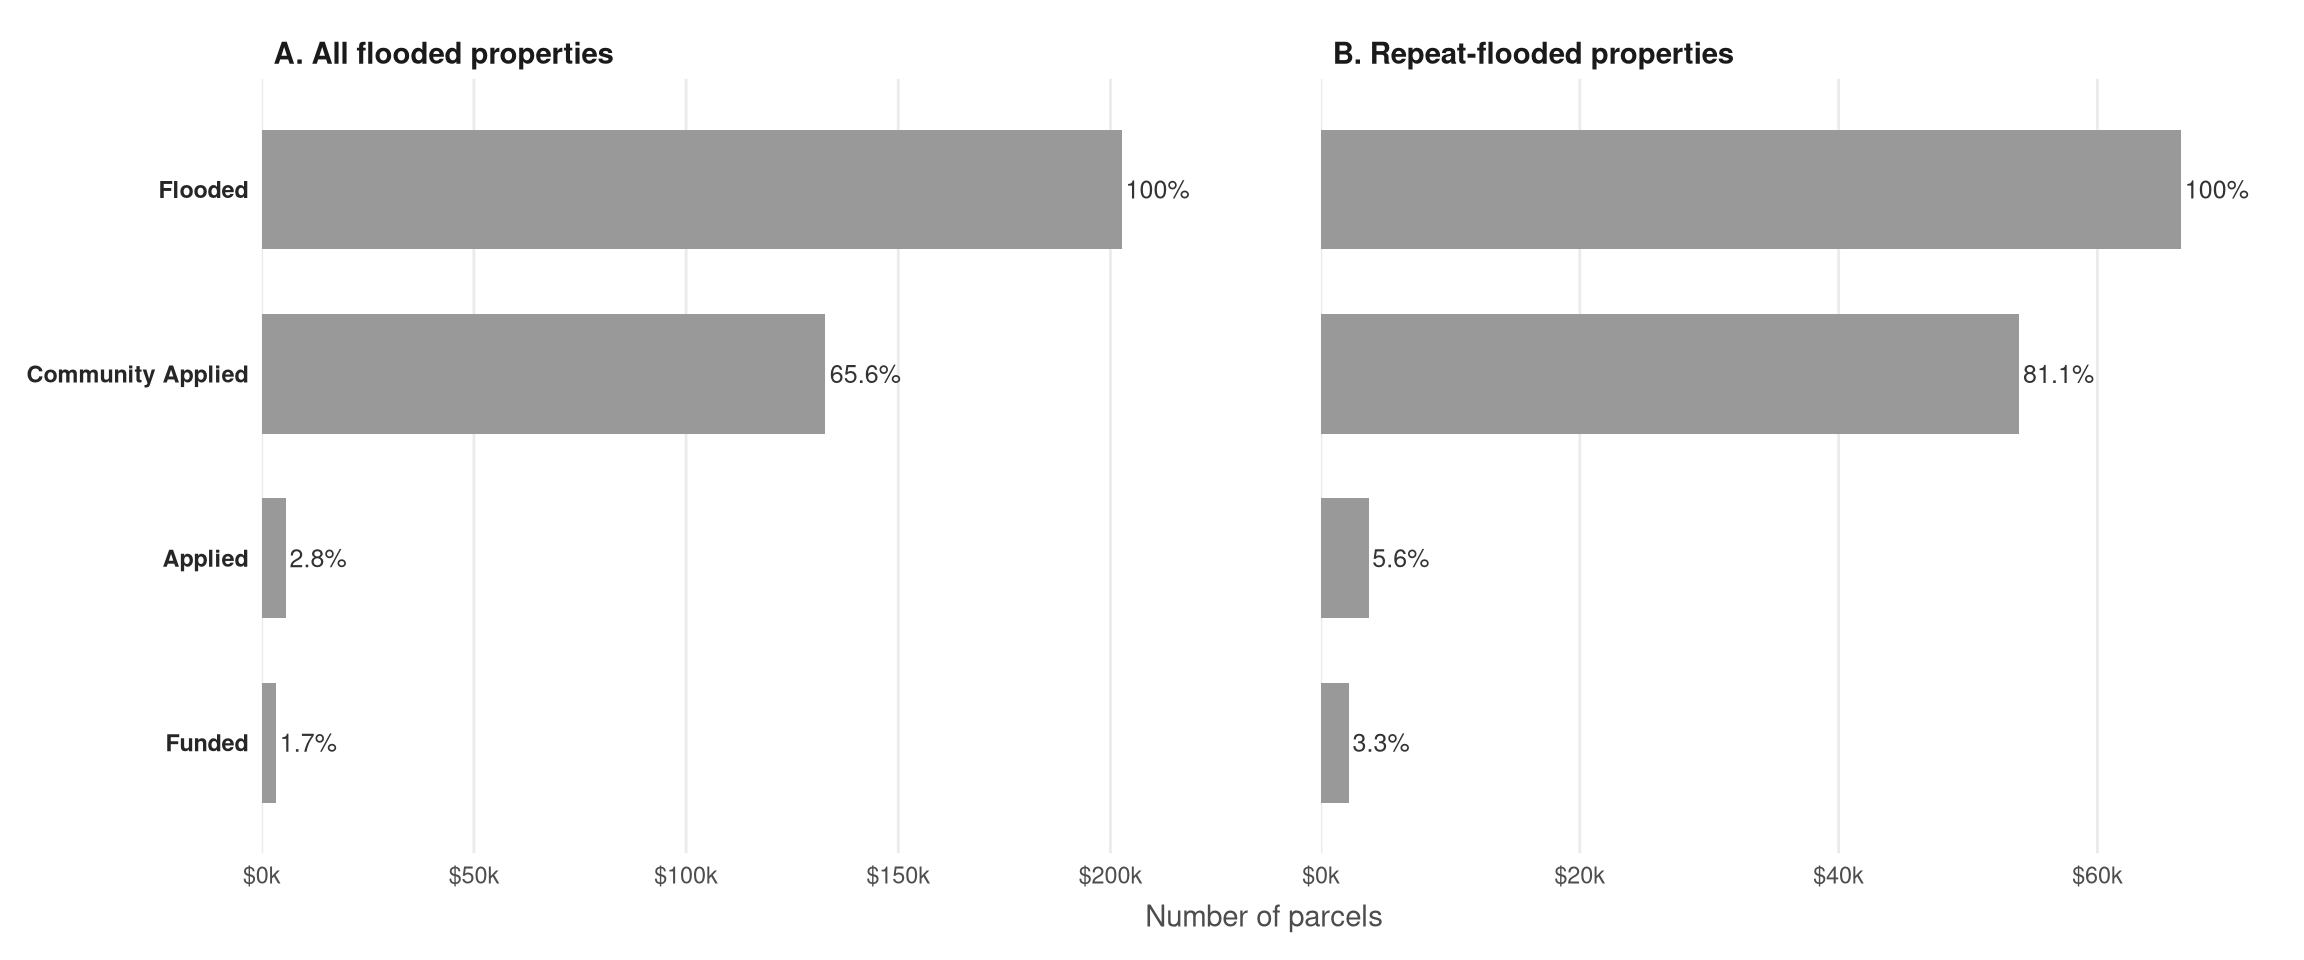

In [ ]:
stage_order_5 <- c("Flooded", "Eligible", "Community Applied",
                   "Applied", "Funded")

panel_labels_2 <- c(
  "All flood-exposed"    = "A. All flooded properties",
  "Repeat flood-exposed" = "B. Repeat-flooded properties"
)

fig2_data <- funnel |>
  filter(stage != "Eligible") |>
  mutate(
    stage = recode(as.character(stage),
                   "In a community" = "Community Applied"),
    stage = factor(stage, levels = c("Flooded", "Community Applied",
                                      "Applied", "Funded")),
    panel = factor(recode(group, !!!panel_labels_2),
                   levels = unname(panel_labels_2)),
    label_text = paste0(round(pct_of_flood * 100, 1), "%")   # ← percentage only
  )

fig2 <- ggplot(fig2_data, aes(x = n, y = stage)) +
  geom_col(fill = "grey60", width = 0.65) +
  geom_text(aes(label = label_text),
            hjust = -0.06, size = 3.3, colour = "grey20") +
  facet_wrap(~ panel, ncol = 2, scales = "free_x") +
  scale_x_continuous(
    expand = expansion(mult = c(0, 0.10)),                    # ← tighter right margin
    labels = scales::label_dollar(scale = 1e-3, suffix = "k")
  ) +
  scale_y_discrete(limits = rev) +
  labs(
    x = "Number of parcels",
    y = NULL
  ) +
  theme_minimal(base_size = 11) +
  theme(
    axis.text.y        = element_text(face = "bold", colour = "grey15"),
    axis.text.x        = element_text(colour = "grey30"),
    axis.title.x       = element_text(colour = "grey30", margin = margin(t = 6)),
    strip.text         = element_text(face = "bold", hjust = 0,
                                      colour = "grey10", size = 11),
    strip.background   = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.grid.minor   = element_blank(),
    panel.spacing.x    = unit(1.5, "cm"),
    plot.title         = element_text(face = "bold"),
    plot.margin        = margin(10, 14, 10, 10)
  )

fig2


In [ ]:
dir.create(here::here("figures"), showWarnings = FALSE)
ggsave(here::here("figures", "fig2.png"),
       fig2, width = 7.48, height = 4, dpi = 300)


------------------------------------------------------------------------

## 7 Fig. 3 — property value distribution by pipeline stage

Each property’s value is converted to a **percentile** against the entire `fr_1_4` study-area sample. Histograms use 5% bins; the red vertical line marks the stage median. Four stages shown (Eligible dropped).

### 7.1 Build the percentile sample

In [ ]:
# Compute Panel B as percentile WITHIN block group instead of EIF cell.
# Filter to BGs with >= 5 parcels for meaningful within-neighborhood rank.
value_df <- pipeline |>
  filter(!is.na(value), value > 0, !is.na(bg_geoid)) |>
  mutate(
    pct_A = dplyr::percent_rank(value) * 100
  ) |>
  group_by(bg_geoid) |>
  mutate(
    bg_n  = dplyr::n(),
    pct_B = if_else(bg_n >= 5, dplyr::percent_rank(value) * 100, NA_real_)
  ) |>
  ungroup()

cat("sample parcels (fr_1_4 OR interp, w/ value + bg):",
    format(nrow(value_df), big.mark = ","), "\n")


sample parcels (fr_1_4 OR interp, w/ value + bg): 3,124,197 

distinct block groups: 4,469 

parcels with valid Panel B percentile (bg_n >= 5): 3,124,144 

### 7.2 Plot

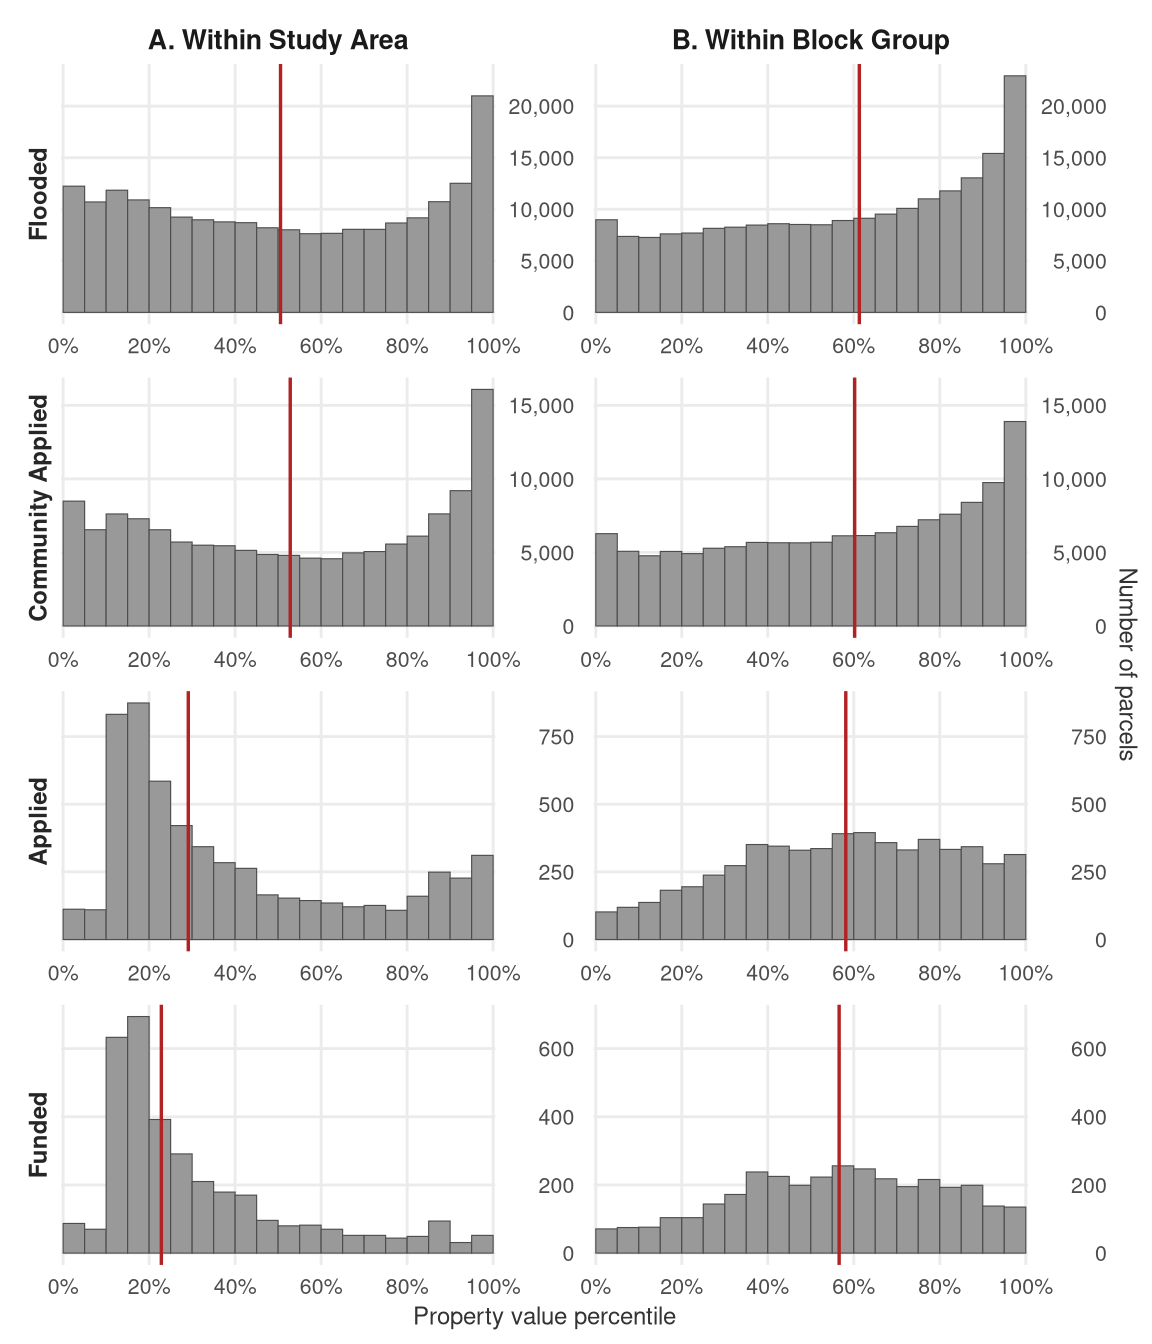

In [ ]:
stage_levels_4 <- c("Flooded", "Community Applied", "Applied", "Funded")

panel_labels_3 <- c(
  pct_A = "A. Within Study Area",
  pct_B = "B. Within Block Group"
)

fig3_hist_data <- bind_rows(
  value_df |> filter(reach1) |> mutate(stage = "Flooded"),
  value_df |> filter(reach3) |> mutate(stage = "Community Applied"),
  value_df |> filter(reach4) |> mutate(stage = "Applied"),
  value_df |> filter(reach5) |> mutate(stage = "Funded")
) |>
  select(stage, pct_A, pct_B) |>
  tidyr::pivot_longer(c(pct_A, pct_B),
                      names_to = "panel", values_to = "pct") |>
  filter(!is.na(pct)) |>
  mutate(
    stage = factor(stage, levels = stage_levels_4),
    panel = factor(recode(panel, !!!panel_labels_3),
                   levels = unname(panel_labels_3))
  )

fig3_medians <- fig3_hist_data |>
  group_by(panel, stage) |>
  summarise(median_pct = median(pct, na.rm = TRUE), .groups = "drop")

fig3 <- ggplot(fig3_hist_data, aes(x = pct)) +
  geom_histogram(binwidth = 5, boundary = 0,
                 fill = "grey60", colour = "grey30", linewidth = 0.2) +
  geom_vline(data = fig3_medians,
             aes(xintercept = median_pct),
             colour = "firebrick", linewidth = 0.6) +
  facet_grid(stage ~ panel,
             scales = "free_y",
             axes = "all",
             switch = "y") +
  scale_y_continuous(position = "right",
                     labels = scales::label_comma()) +
  scale_x_continuous(
    limits = c(0, 100),
    breaks = seq(0, 100, 20),
    labels = function(x) paste0(x, "%"),
    expand = c(0.005, 0)
  ) +
  labs(
    x = "Property value percentile",
    y = "Number of parcels"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    strip.text.x       = element_text(face = "bold", size = 10),
    strip.text.y.left  = element_text(face = "bold", size = 9, angle = 90,
                                      hjust = 0.5, vjust = 0.5, colour = "grey15"),
    strip.background   = element_blank(),
    strip.placement    = "outside",
    panel.grid.minor   = element_blank(),
    panel.spacing      = unit(0.5, "lines"),
    plot.title         = element_text(face = "bold"),
    axis.text          = element_text(size = 8, colour = "grey30"),
    axis.title         = element_text(size = 9, colour = "grey20")
  )

fig3


In [ ]:
readr::write_csv(fig3_medians,
                 here::here("figures", "fig3_medians.csv"))

dir.create(here::here("figures"), showWarnings = FALSE)
ggsave(file.path(here::here("figures"), "fig3.png"),
       fig3, width = 7.5, height = 9, dpi = 300)


------------------------------------------------------------------------

## 8 Fig. 4 — neighborhood racial composition by HMA stage

Two-panel figure following the draft’s Fig. 4 caption. **Panel A** is % Non-Hispanic White residents in the census block group containing each property (2013 ACS). **Panel B** is % Black residents in the same block group. A block group is at stage *k* if it contains ≥ 1 residential parcel that reached *k*. Block-group-level. Four stages shown (Eligible dropped); 5% bins; red line = median.

### 8.1 Build per-panel data

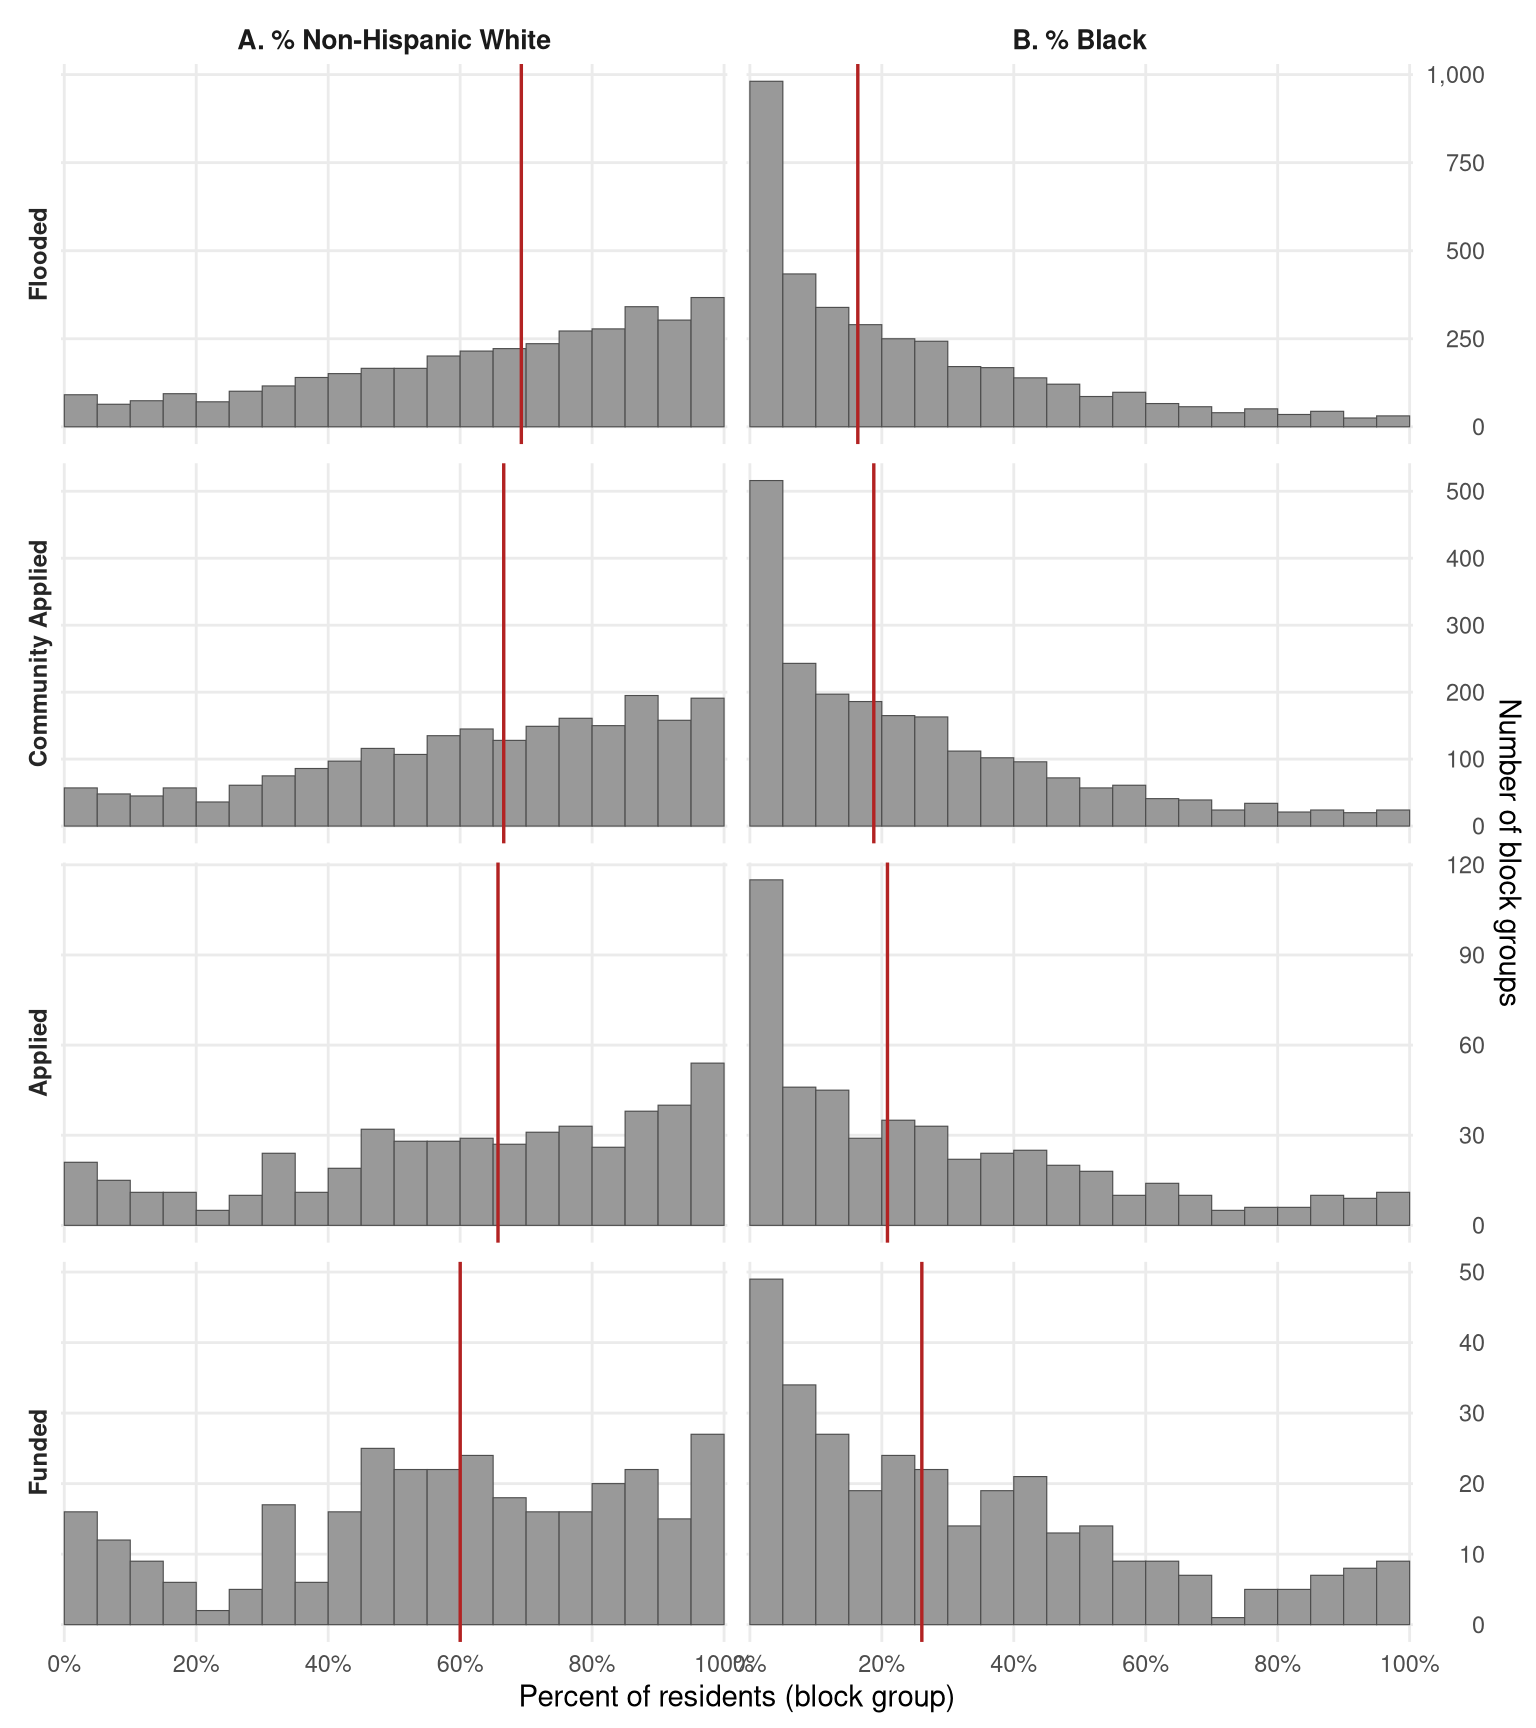

In [ ]:
# Per-block-group race shares — one row per BG, with stage flags.
# bg_pct_white_2013 / bg_pct_black_2013 are already on a 0-100 scale.
bgs_at_stage <- value_df |>
  filter(!is.na(bg_geoid)) |>
  group_by(bg_geoid) |>
  summarise(
    pct_white = dplyr::first(bg_pct_white_2013),
    pct_black = dplyr::first(bg_pct_black_2013),
    s1 = any(reach1, na.rm = TRUE),
    s3 = any(reach3, na.rm = TRUE),
    s4 = any(reach4, na.rm = TRUE),
    s5 = any(reach5, na.rm = TRUE),
    .groups = "drop"
  )

fig4_hist_data <- bgs_at_stage |>
  tidyr::pivot_longer(c(s1, s3, s4, s5),
                      names_to = "stage_key", values_to = "in_stage") |>
  filter(in_stage) |>
  mutate(stage = recode(stage_key,
    s1 = "Flooded", s3 = "Community Applied",
    s4 = "Applied", s5 = "Funded"
  )) |>
  select(stage, pct_white, pct_black) |>
  tidyr::pivot_longer(c(pct_white, pct_black),
                      names_to = "race", values_to = "pct") |>
  filter(!is.na(pct)) |>
  mutate(
    stage = factor(stage, levels = stage_levels_4),
    race  = factor(recode(race,
      pct_white = "A. % Non-Hispanic White",
      pct_black = "B. % Black"
    ), levels = c("A. % Non-Hispanic White", "B. % Black"))
  )

fig4_medians <- fig4_hist_data |>
  group_by(stage, race) |>
  summarise(median_pct = median(pct, na.rm = TRUE), .groups = "drop")

fig4 <- ggplot(fig4_hist_data, aes(x = pct)) +
  geom_histogram(binwidth = 5, boundary = 0,
                 fill = "grey60", colour = "grey30", linewidth = 0.2) +
  geom_vline(data = fig4_medians,
             aes(xintercept = median_pct),
             colour = "firebrick", linewidth = 0.6) +
  facet_grid(stage ~ race, scales = "free_y", switch = "y") +
  scale_x_continuous(limits = c(0, 100), breaks = seq(0, 100, 20),
                     labels = function(x) paste0(x, "%"),
                     expand = c(0.005, 0)) +
  scale_y_continuous(position = "right",
                     labels = scales::label_comma()) +
  labs(
    #title    = "Fig. 4  Neighborhood racial composition by HMA stage",
    #subtitle = "Census block groups, 2013 ACS",
    x        = "Percent of residents (block group)",
    y        = "Number of block groups"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    strip.text.x       = element_text(face = "bold", size = 10),
    strip.text.y.left  = element_text(face = "bold", size = 9, angle = 90,
                                      hjust = 0.5, colour = "grey15"),
    strip.background   = element_blank(),
    strip.placement    = "outside",
    panel.grid.minor   = element_blank(),
    panel.spacing      = unit(0.5, "lines"),
    plot.title         = element_text(face = "bold")
  )

fig4


In [ ]:
# KS tests for racial composition shifts: flooded baseline vs funded stage.
# One observation per block group containing >= 1 parcel reaching each stage.

get_bg_dist <- function(pipeline, stage_flag, race_col) {
  pipeline |>
    dplyr::filter(.data[[stage_flag]],
                  !is.na(.data[[race_col]]),
                  !is.na(bg_geoid)) |>
    dplyr::distinct(bg_geoid, .keep_all = TRUE) |>
    dplyr::pull(.data[[race_col]])
}

stage_flooded <- "reach1"   # cumulative "reached Flooded" boolean
stage_funded  <- "reach5"   # cumulative "reached Funded"  boolean
col_white     <- "bg_pct_white_2013"
col_black     <- "bg_pct_black_2013"

# Distributions (one value per block group at each stage)
white_flood  <- get_bg_dist(pipeline, stage_flooded, col_white)
white_funded <- get_bg_dist(pipeline, stage_funded,  col_white)
black_flood  <- get_bg_dist(pipeline, stage_flooded, col_black)
black_funded <- get_bg_dist(pipeline, stage_funded,  col_black)

# Two-sample KS tests (suppress ties warning for large samples)
ks_white <- suppressWarnings(ks.test(white_funded, white_flood))
ks_black <- suppressWarnings(ks.test(black_funded, black_flood))

# Bundle for downstream use
ks_tests <- list(
  white = list(
    D         = unname(ks_white$statistic),
    p         = ks_white$p.value,
    n_flooded = length(white_flood),
    n_funded  = length(white_funded)
  ),
  black = list(
    D         = unname(ks_black$statistic),
    p         = ks_black$p.value,
    n_flooded = length(black_flood),
    n_funded  = length(black_funded)
  )
)

# Console output for sanity-checking on render
cat("KS tests: flooded baseline vs funded stage (block-group level)\n")


KS tests: flooded baseline vs funded stage (block-group level)

-----------------------------------------------------------

NH White:  D = 0.131   p = < 1e-04   n_flooded = 3677   n_funded = 316

Black:     D = 0.151   p = < 1e-04   n_flooded = 3677   n_funded = 316

### 8.2 Medians table

In [ ]:
fig4_medians |>
  mutate(
    n          = NA_integer_,   # counts live in fig4_hist_data if needed
    median_pct = round(median_pct, 1)
  ) |>
  select(race, stage, median_pct) |>
  arrange(race, stage) |>
  knitr::kable(col.names = c("Panel", "Stage", "Median pct"))


  Panel                     Stage                 Median pct
  ------------------------- ------------------- ------------
  A. % Non-Hispanic White   Flooded                     69.3
  A. % Non-Hispanic White   Community Applied           66.6
  A. % Non-Hispanic White   Applied                     65.7
  A. % Non-Hispanic White   Funded                      60.0
  B. % Black                Flooded                     16.4
  B. % Black                Community Applied           18.8
  B. % Black                Applied                     20.9
  B. % Black                Funded                      26.1


In [ ]:
dir.create(here::here("figures"), showWarnings = FALSE)
ggsave(here::here("figures", "fig4.png"),
       fig4, width = 8, height = 9, dpi = 300)
write_csv(fig4_medians, here::here("figures", "fig4_medians.csv"))


## 9 Fig. 5 — supplementary block-group economic distributions

Block-group medians for household income and home value across the flooded-to-funded pipeline. Block-group-level (one observation per BG that contains a residential parcel reaching the stage). Same 4-stage structure as Fig. 4; same histogram style. Two separate panels because income and home value live on different dollar scales.

### 9.1 Build per-panel data

In [ ]:
# Per-block-group economic medians with stage AND subset flags.
# Subset A: any parcel reaching the stage
# Subset B: any REPEAT-flooded parcel reaching the stage
bgs_econ_at_stage <- value_df |>
  filter(!is.na(bg_geoid)) |>
  group_by(bg_geoid) |>
  summarise(
    income = dplyr::first(bg_median_income_2013),
    hvalue = dplyr::first(bg_median_home_value_2013),
    # All flood-exposed
    s1_all = any(reach1, na.rm = TRUE),
    s3_all = any(reach3, na.rm = TRUE),
    s4_all = any(reach4, na.rm = TRUE),
    s5_all = any(reach5, na.rm = TRUE),
    # Repeat flood-exposed
    s1_rep = any(reach1 & repeat_exp, na.rm = TRUE),
    s3_rep = any(reach3 & repeat_exp, na.rm = TRUE),
    s4_rep = any(reach4 & repeat_exp, na.rm = TRUE),
    s5_rep = any(reach5 & repeat_exp, na.rm = TRUE),
    .groups = "drop"
  )

fig5_long <- bgs_econ_at_stage |>
  tidyr::pivot_longer(c(s1_all, s3_all, s4_all, s5_all,
                        s1_rep, s3_rep, s4_rep, s5_rep),
                      names_to = "stage_subset", values_to = "in_stage") |>
  filter(in_stage) |>
  tidyr::separate(stage_subset, into = c("stage_key", "subset_key"),
                  sep = "_") |>
  mutate(
    stage = recode(stage_key,
      s1 = "Flooded", s3 = "Community Applied",
      s4 = "Applied", s5 = "Funded"
    ),
    stage = factor(stage, levels = stage_levels_4),
    subset = factor(recode(subset_key,
      all = "A. All flood-exposed",
      rep = "B. Repeat flood-exposed"
    ), levels = c("A. All flood-exposed", "B. Repeat flood-exposed"))
  ) |>
  select(bg_geoid, stage, subset, income, hvalue)

fig5_income <- fig5_long |>
  select(stage, subset, val = income) |>
  filter(!is.na(val))

fig5_hvalue <- fig5_long |>
  select(stage, subset, val = hvalue) |>
  filter(!is.na(val))

# Medians by stage AND subset
fig5_medians <- bind_rows(
  fig5_income |> group_by(stage, subset) |>
    summarise(median_val = median(val, na.rm = TRUE), .groups = "drop") |>
    mutate(metric = "income"),
  fig5_hvalue |> group_by(stage, subset) |>
    summarise(median_val = median(val, na.rm = TRUE), .groups = "drop") |>
    mutate(metric = "hvalue")
)

knitr::kable(
  fig5_medians |>
    mutate(median_val = round(median_val, 0)) |>
    arrange(metric, stage, subset),
  caption = "Fig 5 supplementary medians by stage and subset"
)


  stage               subset                      median_val metric
  ------------------- ------------------------- ------------ --------
  Flooded             A. All flood-exposed            129500 hvalue
  Flooded             B. Repeat flood-exposed         119200 hvalue
  Community Applied   A. All flood-exposed            124850 hvalue
  Community Applied   B. Repeat flood-exposed         116150 hvalue
  Applied             A. All flood-exposed            124350 hvalue
  Applied             B. Repeat flood-exposed         117850 hvalue
  Funded              A. All flood-exposed            109050 hvalue
  Funded              B. Repeat flood-exposed         107900 hvalue
  Flooded             A. All flood-exposed             43280 income
  Flooded             B. Repeat flood-exposed          41991 income
  Community Applied   A. All flood-exposed             42955 income
  Community Applied   B. Repeat flood-exposed          42000 income
  Applied             A. All flood-exposed             42282 income
  Applied             B. Repeat flood-exposed          41985 income
  Funded              A. All flood-exposed             40694 income
  Funded              B. Repeat flood-exposed          41278 income

  : Fig 5 supplementary medians by stage and subset


### 9.2 Panel A — household income

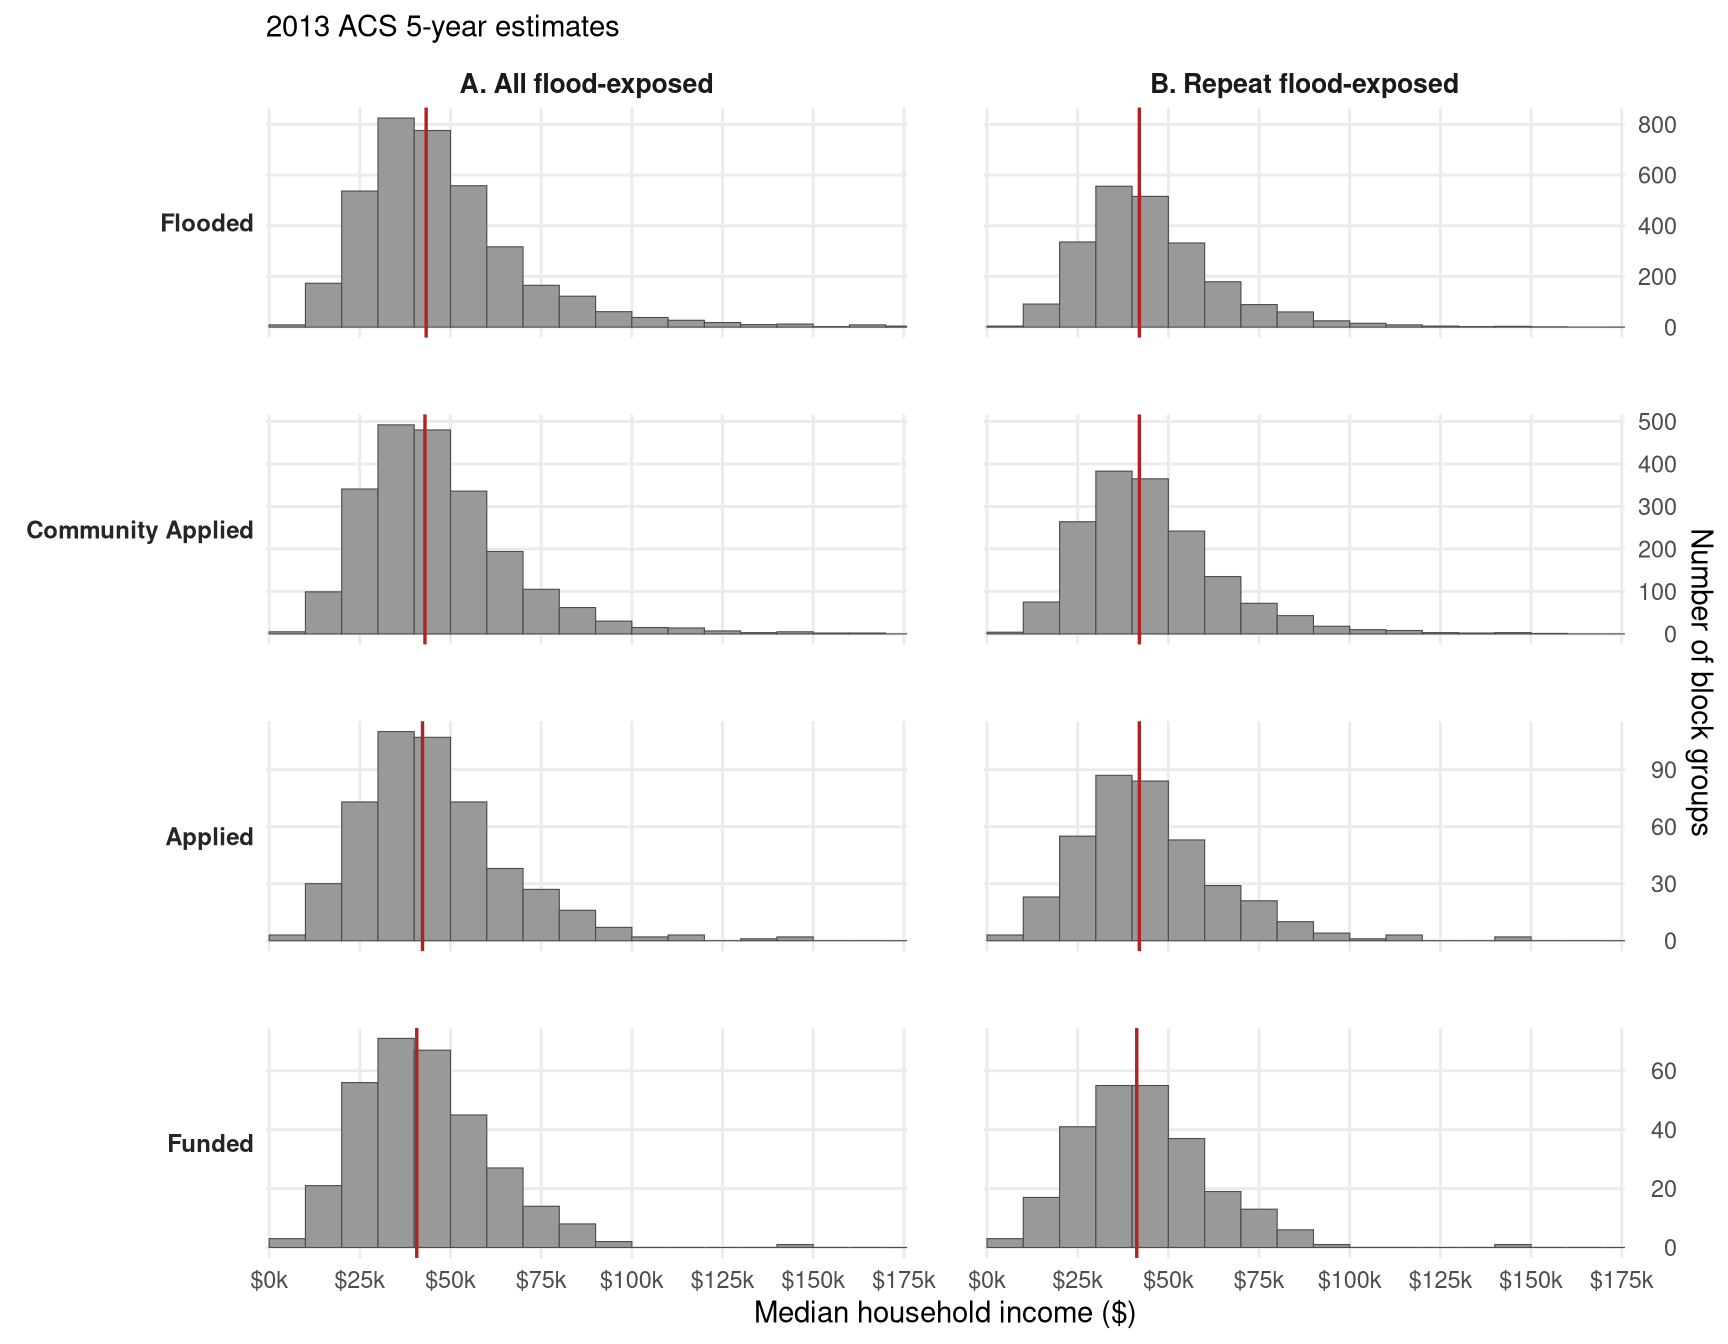

In [ ]:
inc_medians <- fig5_medians |> filter(metric == "income")

fig5a <- ggplot(fig5_income, aes(x = val)) +
  geom_histogram(binwidth = 10000, boundary = 0,
                 fill = "grey60", colour = "grey30", linewidth = 0.2) +
  geom_vline(data = inc_medians,
             aes(xintercept = median_val),
             colour = "firebrick", linewidth = 0.6) +
  facet_grid(stage ~ subset, scales = "free_y", switch = "y") +
  coord_cartesian(xlim = c(0, 175000)) +
  scale_x_continuous(
    breaks = seq(0, 175000, 25000),
    labels = scales::label_dollar(scale = 1e-3, suffix = "k"),
    expand = c(0.005, 0)
  ) +
  scale_y_continuous(position = "right",
                     labels = scales::label_comma()) +
  labs(
    subtitle = "2013 ACS 5-year estimates",
    x        = "Median household income ($)",
    y        = "Number of block groups"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    strip.text.x       = element_text(face = "bold", size = 10),
    strip.text.y.left  = element_text(face = "bold", size = 9, angle = 0,
                                       hjust = 1, colour = "grey15"),
    strip.background   = element_blank(),
    strip.placement    = "outside",
    panel.grid.minor   = element_blank(),
    panel.spacing      = unit(2, "lines"),
    plot.title         = element_text(face = "bold")
  )

fig5a


### 9.3 Panel B — home value

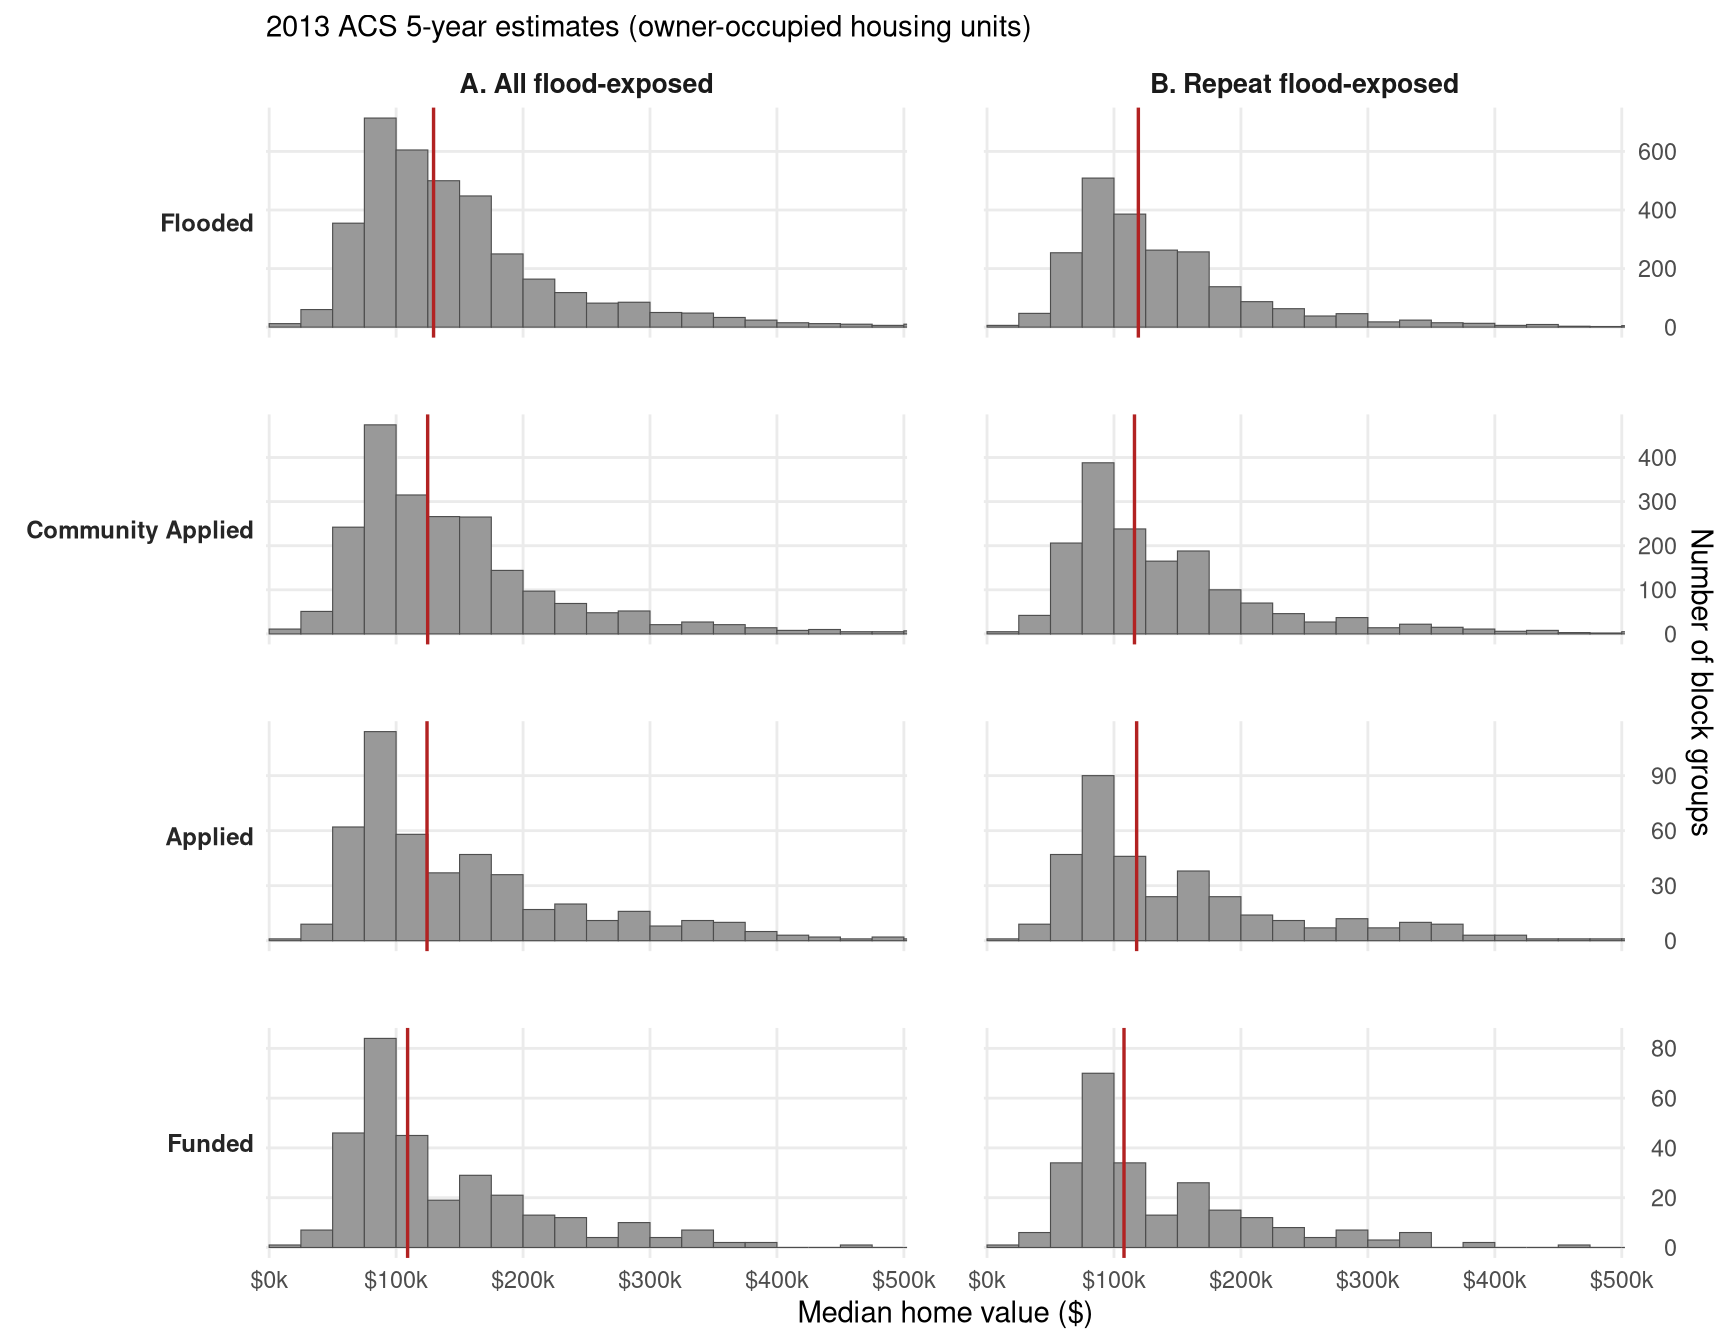

In [ ]:
hv_medians <- fig5_medians |> filter(metric == "hvalue")

fig5b <- ggplot(fig5_hvalue, aes(x = val)) +
  geom_histogram(binwidth = 25000, boundary = 0,
                 fill = "grey60", colour = "grey30", linewidth = 0.2) +
  geom_vline(data = hv_medians,
             aes(xintercept = median_val),
             colour = "firebrick", linewidth = 0.6) +
  facet_grid(stage ~ subset, scales = "free_y", switch = "y") +
  coord_cartesian(xlim = c(0, 500000)) +
  scale_x_continuous(
    breaks = seq(0, 500000, 100000),
    labels = scales::label_dollar(scale = 1e-3, suffix = "k"),
    expand = c(0.005, 0)
  ) +
  scale_y_continuous(position = "right",
                     labels = scales::label_comma()) +
  labs(
    subtitle = "2013 ACS 5-year estimates (owner-occupied housing units)",
    x        = "Median home value ($)",
    y        = "Number of block groups"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    strip.text.x       = element_text(face = "bold", size = 10),
    strip.text.y.left  = element_text(face = "bold", size = 9, angle = 0,
                                       hjust = 1, colour = "grey15"),
    strip.background   = element_blank(),
    strip.placement    = "outside",
    panel.grid.minor   = element_blank(),
    panel.spacing      = unit(2, "lines"),
    plot.title         = element_text(face = "bold")
  )

fig5b


### 9.4 Save

In [ ]:
dir.create(here::here("figures"), showWarnings = FALSE)
ggsave(here::here("figures", "fig5a_income.png"),
       fig5a, width = 6, height = 7, dpi = 300)
ggsave(here::here("figures", "fig5b_home_value.png"),
       fig5b, width = 6, height = 7, dpi = 300)
write_csv(fig5_medians, here::here("figures", "fig5_medians.csv"))


## Buyouts vs Elevations

In [ ]:
# Load the parcel-level classification produced in step 05
parcel_mit_type <- readr::read_csv(
  file.path(out_dir, "parcel_mit_type.csv"),
  show_col_types = FALSE
) |>
  dplyr::mutate(parcel_index = as.integer(parcel_index))

# --- Build funded subset with mit_type ------------------------------------
# Universe = flooded funded parcels (matches the funnel's reach5 = reach4 & funded)
funded_typed <- pipeline |>
  dplyr::filter(reach5) |>
  dplyr::left_join(parcel_mit_type |> dplyr::select(parcel_index, mit_type),
                   by = "parcel_index") |>
  dplyr::mutate(mit_type = dplyr::if_else(is.na(mit_type),
                                          "Other/Unknown", mit_type))

# --- Counts table ---------------------------------------------------------
type_counts <- funded_typed |>
  dplyr::count(mit_type, name = "n") |>
  dplyr::mutate(
    pct_of_all        = round(n / sum(n) * 100, 1),
    pct_of_classified = dplyr::if_else(
      mit_type %in% c("Buyout", "Elevation"),
      round(n / sum(n[mit_type %in% c("Buyout", "Elevation")]) * 100, 1),
      NA_real_
    )
  ) |>
  dplyr::arrange(dplyr::desc(n))

cat("Funded parcels by mitigation type (universe = funnel reach5):\n")


Funded parcels by mitigation type (universe = funnel reach5):

       mit_type    n pct_of_all pct_of_classified
1        Buyout 1879       54.7              81.9
2 Other/Unknown 1138       33.2                NA
3     Elevation  415       12.1              18.1


Buyout + Elevation subset: 2,294 parcels (1,405 repeat-flooded)


=== KS tests (Buyout vs Elevation) ===

Property value:

...

  Panel B (repeat-flooded):   D = 0.135  p = 0.00030369  (n_buy = 1095, n_elev = 310)

% Black:

  Panel A (all funded):       D = 0.366  p = < 1e-04  (n_buy = 1879, n_elev = 415)

  Panel B (repeat-flooded):   D = 0.320  p = < 1e-04  (n_buy = 1095, n_elev = 310)


Wrote figS2_mit_type_value.png and figS3_mit_type_black.png

### Buyouts vs Elevations: Main Text (no rep loss)

In [ ]:
# Filter to "All funded" panel only for main text figure
val_data_main   <- val_data   |> filter(panel == "A. All funded")
black_data_main <- black_data |> filter(panel == "A. All funded")

val_medians_main   <- val_medians   |> filter(panel == "A. All funded")
black_medians_main <- black_medians |> filter(panel == "A. All funded")

# Pull both metrics into long form for one shared figure
mit_combined <- bind_rows(
  val_data_main |>
    transmute(mit_type, x, metric = "A. Study-area property-value percentile"),
  black_data_main |>
    transmute(mit_type, x, metric = "B. Block-group % Black residents")
) |>
  mutate(metric = factor(metric,
    levels = c("A. Study-area property-value percentile",
               "B. Block-group % Black residents")))

mit_combined_medians <- bind_rows(
  val_medians_main |>
    transmute(mit_type, median_x, metric = "A. Study-area property-value percentile"),
  black_medians_main |>
    transmute(mit_type, median_x, metric = "B. Block-group % Black residents")
) |>
  mutate(metric = factor(metric,
    levels = c("A. Study-area property-value percentile",
               "B. Block-group % Black residents")))

fig_mit_type <- ggplot(mit_combined, aes(x = x, fill = mit_type)) +
  geom_histogram(binwidth = 5, boundary = 0,
                 position = "identity", alpha = 0.55,
                 colour = "grey30", linewidth = 0.15) +
  geom_vline(data = mit_combined_medians,
             aes(xintercept = median_x, colour = mit_type),
             linetype = "dashed", linewidth = 0.6, show.legend = FALSE) +
  facet_wrap(~ metric, nrow = 1, scales = "free_y") +
  scale_fill_manual(values = c("Buyout" = "#1f78b4", "Elevation" = "#e31a1c"),
                    name = "Mitigation type") +
  scale_colour_manual(values = c("Buyout" = "#1f78b4", "Elevation" = "#e31a1c")) +
  scale_x_continuous(limits = c(0, 100), breaks = seq(0, 100, 20),
                     labels = function(x) paste0(x, "%"),
                     expand = c(0.005, 0)) +
  scale_y_continuous(labels = scales::label_comma()) +
  labs(x = NULL, y = "Number of funded parcels") +
  theme_minimal(base_size = 11) +
  theme(
    legend.position  = "top",
    strip.text       = element_text(face = "bold", size = 10),
    panel.grid.minor = element_blank(),
    panel.spacing    = unit(2, "lines")
  )

ggsave(file.path(fig_dir, "fig5_mit_type.png"),
       plot = fig_mit_type, width = 8, height = 4, dpi = 300, bg = "white")


## Supplementary Material

### 10 Sensitivity analysis — drop 7 high-uncertainty events

Verifies that the headline funnel rates and demographic-composition shifts are robust to excluding the 7 events Garcia et al. (2025) flag for unusually high modeled-to-observed damage ratios (`bld_claims_ratio > 20`).

The sensitivity counts (`flooded_any_sens`, `eligible_sens`) are produced by step 07 and saved as `parcels_events_R_sens.csv`. Here we rebuild the pipeline using those counts and recompute funnel + figure medians for comparison.

In [ ]:
sens_counts <- readr::read_csv(
  file.path(out_dir, "parcels_events_R_sens.csv"),
  show_col_types = FALSE
) |>
  dplyr::mutate(parcel_index = as.integer(parcel_index))

cat("Loaded sensitivity counts for",
    format(nrow(sens_counts), big.mark = ","), "parcels\n")


Loaded sensitivity counts for 4,041,245 parcels

In [ ]:
# Build a parallel pipeline_sens using sensitivity flood/eligibility flags
pipeline_sens <- pipeline |>
  dplyr::left_join(sens_counts, by = "parcel_index") |>
  dplyr::mutate(
    flooded_any_sens = dplyr::coalesce(flooded_any_sens, 0L),
    eligible_sens    = dplyr::coalesce(eligible_sens,    0L),
    
    s1_flooded_sens  = flooded_any_sens >= 1,
    s2_eligible_sens = eligible_sens    >= 1,
    repeat_exp_sens  = flooded_any_sens >= 2,
    
    reach1_sens = s1_flooded_sens,
    reach2_sens = reach1_sens & s2_eligible_sens,
    reach3_sens = reach2_sens & s3_community,
    reach4_sens = reach3_sens & s4_applied,
    reach5_sens = reach4_sens & s5_funded
  )

# Build sensitivity funnel
funnel_for_sens <- function(df, label) {
  r <- c(sum(df$reach1_sens), sum(df$reach2_sens), sum(df$reach3_sens),
         sum(df$reach4_sens), sum(df$reach5_sens))
  tibble::tibble(
    group        = label,
    stage_num    = 1:5,
    stage        = factor(
      c("Flooded", "Eligible", "Community Applied", "Applied", "Funded"),
      levels = c("Flooded", "Eligible", "Community Applied",
                 "Applied", "Funded")),
    n            = r,
    pct_of_prev  = c(NA, r[-1] / r[-5]),
    pct_of_flood = r / r[1]
  )
}

funnel_sens_all    <- funnel_for_sens(pipeline_sens,
                                      "Sensitivity all (71 events)")
funnel_sens_repeat <- funnel_for_sens(
  pipeline_sens |> dplyr::filter(repeat_exp_sens),
  "Sensitivity repeat (71 events)"
)


### Funnel comparison

In [ ]:
funnel_compare <- dplyr::bind_rows(
  funnel_all      |> dplyr::mutate(scenario = "Baseline (78)"),
  funnel_sens_all |> dplyr::mutate(scenario = "Sensitivity (71)")
) |>
  dplyr::select(scenario, stage, n, pct_of_prev, pct_of_flood)

funnel_compare |>
  dplyr::mutate(
    n            = format(n, big.mark = ","),
    `% of prev`  = dplyr::if_else(is.na(pct_of_prev), "—",
                                  paste0(round(pct_of_prev * 100, 1), "%")),
    `% of flood` = paste0(round(pct_of_flood * 100, 1), "%")
  ) |>
  dplyr::select(scenario, stage, n, `% of prev`, `% of flood`) |>
  knitr::kable(
    caption = "Baseline (78 events) vs Sensitivity (71 events) funnel"
  )


  scenario           stage               n         \% of prev   \% of flood
  ------------------ ------------------- --------- ------------ -------------
  Baseline (78)      Flooded             202,623   ---          100%
  Baseline (78)      Eligible            141,253   69.7%        69.7%
  Baseline (78)      Community Applied   132,828   94%          65.6%
  Baseline (78)      Applied             5,746     4.3%         2.8%
  Baseline (78)      Funded              3,432     59.7%        1.7%
  Sensitivity (71)   Flooded             172,329   ---          100%
  Sensitivity (71)   Eligible            129,685   75.3%        75.3%
  Sensitivity (71)   Community Applied   121,713   93.9%        70.6%
  Sensitivity (71)   Applied             5,259     4.3%         3.1%
  Sensitivity (71)   Funded              3,354     63.8%        1.9%

  : Baseline (78 events) vs Sensitivity (71 events) funnel


### Sensitivity medians

In [ ]:
# Property value percentile (Panel A) at sensitivity-funded stage
# Use the same study-area-wide percentile rank computed in value_df
sens_med_value_A <- value_df |>
  dplyr::filter(parcel_index %in%
                  (pipeline_sens |> dplyr::filter(reach5_sens) |>
                     dplyr::pull(parcel_index))) |>
  dplyr::summarise(med_pct_A = round(median(pct_A, na.rm = TRUE), 1)) |>
  dplyr::pull(med_pct_A)

# Block-group race medians at sensitivity-funded stage
sens_med_race <- pipeline_sens |>
  dplyr::filter(reach5_sens, !is.na(bg_geoid)) |>
  dplyr::distinct(bg_geoid, .keep_all = TRUE) |>
  dplyr::summarise(
    med_white = round(median(bg_pct_white_2013, na.rm = TRUE), 1),
    med_black = round(median(bg_pct_black_2013, na.rm = TRUE), 1),
    n_bg      = dplyr::n_distinct(bg_geoid)
  )

# Pull baseline medians from fig3 / fig4 medians tables
baseline_med_value_A <- fig3_medians$median_pct[
  fig3_medians$panel == "A. Within Study Area" &
  fig3_medians$stage == "Funded"
]
baseline_med_white <- fig4_medians$median_pct[
  fig4_medians$race == "A. % Non-Hispanic White" &
  fig4_medians$stage == "Funded"
]
baseline_med_black <- fig4_medians$median_pct[
  fig4_medians$race == "B. % Black" &
  fig4_medians$stage == "Funded"
]

sens_med_table <- tibble::tibble(
  Metric = c("Property value (Panel A pctile)",
             "NH White share (BG, %)",
             "Black share (BG, %)"),
  `Baseline (78)` = c(baseline_med_value_A,
                      baseline_med_white,
                      baseline_med_black),
  `Sensitivity (71)` = c(sens_med_value_A,
                         sens_med_race$med_white,
                         sens_med_race$med_black)
)

knitr::kable(sens_med_table,
             caption = "Funded-stage medians: baseline vs sensitivity")


  Metric                              Baseline (78)   Sensitivity (71)
  --------------------------------- --------------- ------------------
  Property value (Panel A pctile)          22.83615               22.9
  NH White share (BG, %)                   60.00840               59.6
  Black share (BG, %)                      26.06518               26.3

  : Funded-stage medians: baseline vs sensitivity


### Sensitivity KS tests

In [ ]:
get_bg_dist_sens <- function(df, stage_flag, race_col) {
  df |>
    dplyr::filter(.data[[stage_flag]],
                  !is.na(.data[[race_col]]),
                  !is.na(bg_geoid)) |>
    dplyr::distinct(bg_geoid, .keep_all = TRUE) |>
    dplyr::pull(.data[[race_col]])
}

white_flood_sens  <- get_bg_dist_sens(pipeline_sens, "reach1_sens", "bg_pct_white_2013")
white_funded_sens <- get_bg_dist_sens(pipeline_sens, "reach5_sens", "bg_pct_white_2013")
black_flood_sens  <- get_bg_dist_sens(pipeline_sens, "reach1_sens", "bg_pct_black_2013")
black_funded_sens <- get_bg_dist_sens(pipeline_sens, "reach5_sens", "bg_pct_black_2013")

ks_white_sens <- suppressWarnings(ks.test(white_funded_sens, white_flood_sens))
ks_black_sens <- suppressWarnings(ks.test(black_funded_sens, black_flood_sens))

ks_compare <- tibble::tibble(
  Distribution = c("NH White", "Black"),
  `Baseline D` = c(round(ks_tests$white$D, 3),
                   round(ks_tests$black$D, 3)),
  `Sensitivity D` = c(round(unname(ks_white_sens$statistic), 3),
                      round(unname(ks_black_sens$statistic), 3)),
  `Sensitivity p` = c(format.pval(ks_white_sens$p.value, eps = 1e-4),
                      format.pval(ks_black_sens$p.value, eps = 1e-4))
)

knitr::kable(ks_compare,
             caption = "KS tests (flooded vs funded BG distributions) — baseline vs sensitivity")


  Distribution     Baseline D   Sensitivity D Sensitivity p
  -------------- ------------ --------------- ---------------
  NH White              0.131           0.146 \< 1e-04
  Black                 0.151           0.162 \< 1e-04

  : KS tests (flooded vs funded BG distributions) --- baseline vs
  sensitivity


### Bundle sensitivity results

In [ ]:
sensitivity_analysis <- list(
  excluded_events = c(
    "Unnamed Piedmont flooding b (2003)", "TS Andrea (2013)",
    "TS Allison (2001)", "Unnamed western flooding (2000)",
    "Unnamed western flooding (2006)", "Unnamed western flooding (2003)",
    "Unnamed eastern flooding (2004)"
  ),
  funnel_baseline    = funnel_all,
  funnel_sens        = funnel_sens_all,
  funnel_sens_repeat = funnel_sens_repeat,
  funnel_compare     = funnel_compare,
  med_value_A_sens   = sens_med_value_A,
  med_white_sens     = sens_med_race$med_white,
  med_black_sens     = sens_med_race$med_black,
  n_bg_sens          = sens_med_race$n_bg,
  ks_white_sens      = list(D = unname(ks_white_sens$statistic),
                            p = ks_white_sens$p.value),
  ks_black_sens      = list(D = unname(ks_black_sens$statistic),
                            p = ks_black_sens$p.value)
)


### Race and Property Value Correlation

Block groups with complete race + home value data: 4,384 


Block-group correlations (2013 ACS, n = 4,384 ):

NH White x Home value:  Spearman rho = +0.502

Black x Home value:     Spearman rho = -0.467

NH White x Income:      Spearman rho = +0.504

Black x Income:         Spearman rho = -0.463

ℹ Please use the `linewidth` argument instead.

`geom_smooth()` using formula = 'y ~ x'

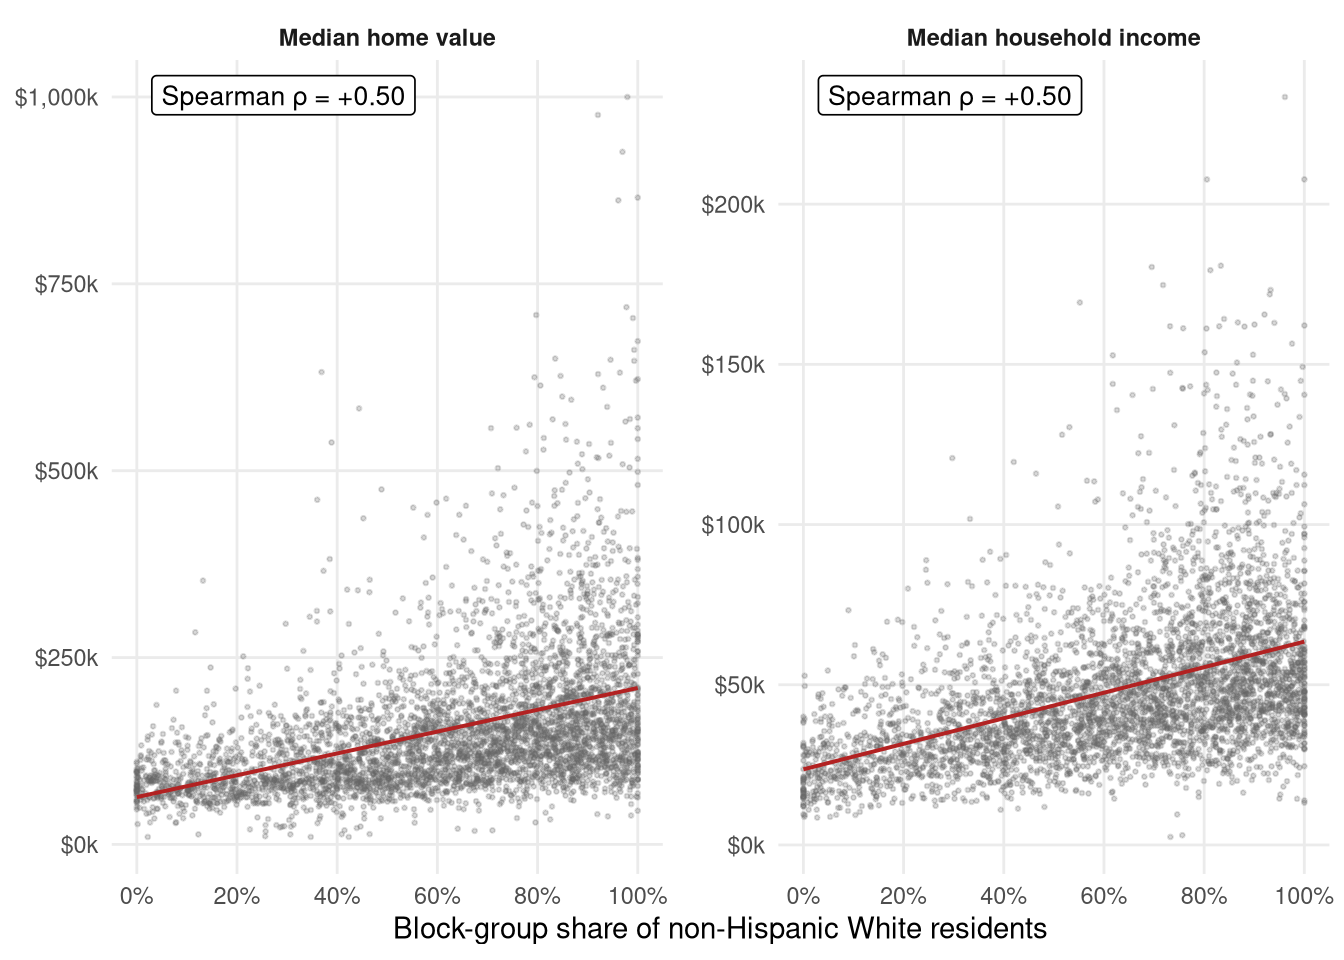

`geom_smooth()` using formula = 'y ~ x'


Wrote figS1_race_value_correlation.png

In [ ]:
# Block-group level correlation between race and property value
# Supports the Discussion claim that less-white neighborhoods tend to be lower-value
# in eastern North Carolina (2013 ACS)

# One observation per block group with complete demographic and value data
bg_demo <- parcels |>
  filter(!is.na(bg_geoid)) |>
  group_by(bg_geoid) |>
  summarise(
    pct_white         = dplyr::first(bg_pct_white_2013),
    pct_black         = dplyr::first(bg_pct_black_2013),
    median_income     = dplyr::first(bg_median_income_2013),
    median_home_value = dplyr::first(bg_median_home_value_2013),
    .groups = "drop"
  ) |>
  filter(!is.na(pct_white),
         !is.na(median_home_value),
         median_home_value > 0)

cat("Block groups with complete race + home value data:",
    format(nrow(bg_demo), big.mark = ","), "\n")


In [ ]:
# Pre-compute everything the manuscript prose references inline.
# Saved as a single small RDS so index.qmd can read it without touching
# parcels_master.gpkg — making the manuscript renderable from any machine.

index_inputs <- list(
  n_sample        = sum(parcels$res_flag == 1L | parcels$interpolate == 1L,
                        na.rm = TRUE),
  n_counties      = length(unique(parcels$county)),
  n_bg            = length(unique(parcels$bg_geoid[!is.na(parcels$bg_geoid)])),
  funnel          = funnel,
  fig3_medians    = fig3_medians,
  fig4_medians    = fig4_medians,
  fig5_medians    = fig5_medians,                    # ← comma added
  ks_tests        = ks_tests,                        # ← comma added
  mit_type_analysis    = mit_type_analysis,
  race_value_cor       = race_value_cor,
  sensitivity_analysis = sensitivity_analysis
)

# Also pull the CoreLogic-vs-ACS agreement summary from 07b's output, if it exists.
# Wrapped in tryCatch so Step 8 still runs cleanly if the file isn't there yet.
acs_cl_summary <- tryCatch({
  cmp <- readr::read_csv(file.path(out_dir, "acs_corelogic_value_comparison.csv"),
                         show_col_types = FALSE)
  list(
    n_bgs            = nrow(cmp),
    spearman_rho     = cor(cmp$cl_median_tvc, cmp$bg_median_home_value_2013,
                           method = "spearman"),
    median_ratio     = median(cmp$cl_median_tvc / cmp$bg_median_home_value_2013,
                              na.rm = TRUE)
  )
}, error = function(e) NULL)

index_inputs$acs_cl_summary <- acs_cl_summary

saveRDS(index_inputs, here::here("figures", "index_inputs.rds"))
cat("Wrote index_inputs.rds with", length(index_inputs), "elements\n")


Wrote index_inputs.rds with 12 elements